In [12]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor

from src.baseline import *

In [13]:
df = pd.read_csv('../data/raw/diamonds.csv', index_col=0)

X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
baseline_results = run_baseline_cv(
    X_train,
    y_train,
    cv_splits=5,
    n_jobs=2
)

baseline_results

Evaluating: Dummy
Evaluating: Linear Regression
Evaluating: Random Forest
Evaluating: Hist Gradient Boosting


,model,cv_rmse_mean,cv_rmse_std
0,Hist Gradient Boosting,560.507236,9.208660
1,Random Forest,564.261314,8.839520
2,Linear Regression,1130.671267,34.739137
3,Dummy,3990.015117,29.181229


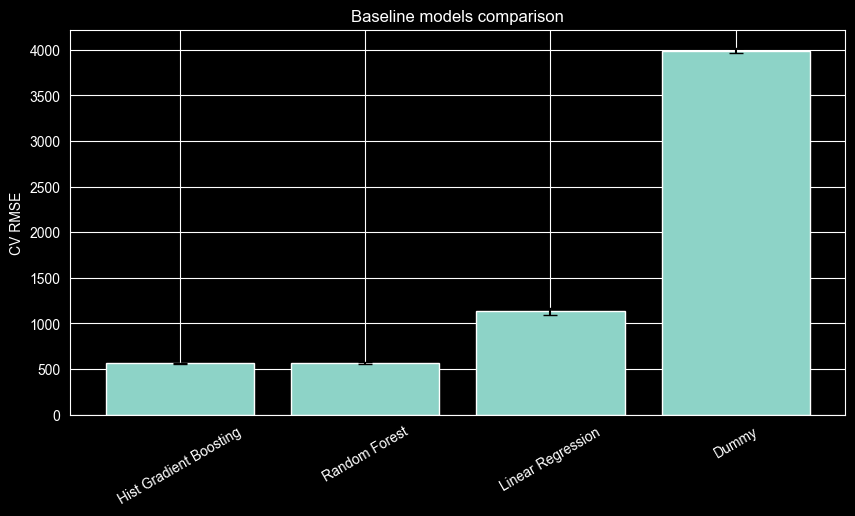

In [15]:
plot_baseline_results(baseline_results)

In [16]:
best_pipeline = fit_model(
    X_train,
    y_train,
    HistGradientBoostingRegressor(random_state=42)
)

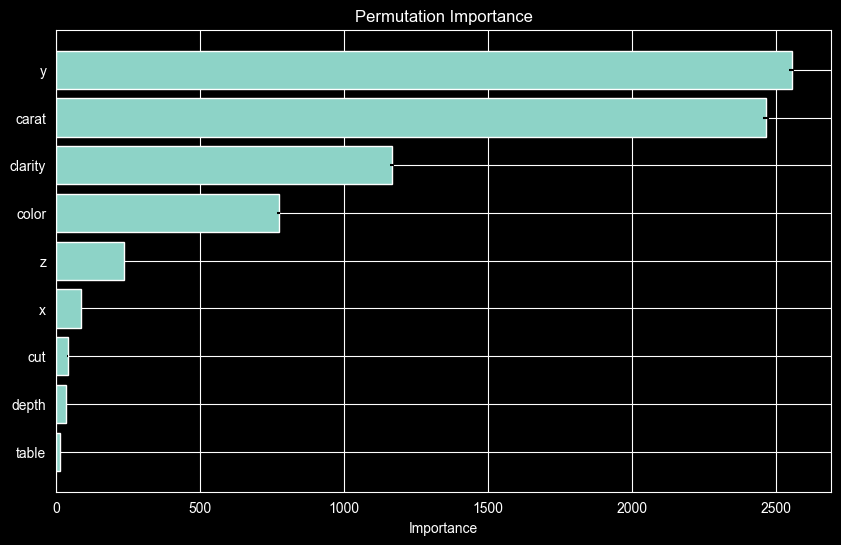

,feature,importance_mean,importance_std
7,y,2553.707574,9.157878
0,carat,2464.879687,9.670472
3,clarity,1166.681804,5.896203
2,color,772.921855,4.690847
8,z,235.163541,0.880125
6,x,85.747436,0.434695
1,cut,39.642536,0.529937
4,depth,35.193641,0.868347
5,table,12.871701,0.452000


In [17]:
plot_permutation_importance(
    best_pipeline,
    X_train,
    y_train,
    top_n=15,
    n_jobs=2
)

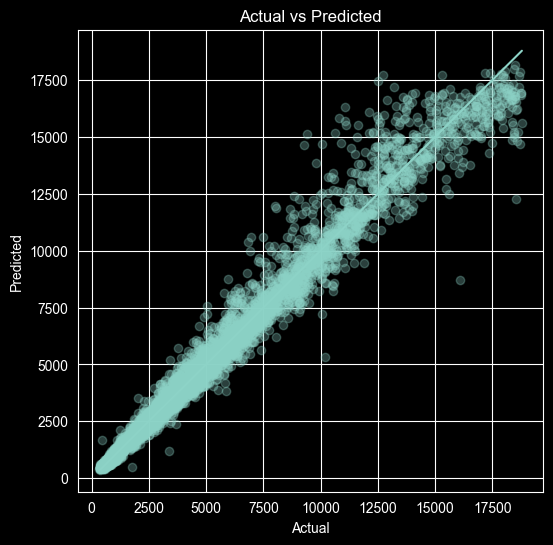

In [18]:
plot_actual_vs_predicted(
    best_pipeline,
    X_train,
    y_train
)

In [19]:
evaluate_on_validation(
    best_pipeline,
    X_train,
    y_train
)

{'RMSE': 560.9577355018696, 'MAE': 288.8288666674425, 'R2': 0.9800302200661746}